In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.environment import HotelPricingEnv

In [2]:
env = HotelPricingEnv()
results = []
for episode in range(50):
    state,_ = env.reset()
    total_reward = 0
    total_rooms_sold = 0
    done = False
    while not done:
        action = np.random.randint(0,5)
        state,reward,done,_,info = env.step(action)
        total_reward += reward
        total_rooms_sold += info["rooms_sold"]
    results.append({
        "Episode": episode + 1,
        "Revenue": total_reward,
        "Rooms Sold": total_rooms_sold,
        "Rooms Remaining": state[0]
    })

results_df = pd.DataFrame(results)

results_df.head()

,Episode,Revenue,Rooms Sold,Rooms Remaining
0,1,5780,50,0
1,2,6220,50,0
2,3,5740,50,0
3,4,5820,50,0
4,5,5180,50,0


In [3]:
results_df.to_csv(r"..\data\processed\simulation_results.csv",index=False)

print("Simulation results saved successfully.")

Simulation results saved successfully.


In [4]:
print("Average Revenue: ",results_df["Revenue"].mean())
print("Maximum Revenue: ",results_df["Revenue"].max())
print("Minimum Revenue: ",results_df["Revenue"].min())
print("Average Rooms Sold: ",results_df["Rooms Sold"].mean())

Average Revenue:  5461.6
Maximum Revenue:  6220
Minimum Revenue:  4560
Average Rooms Sold:  50.0


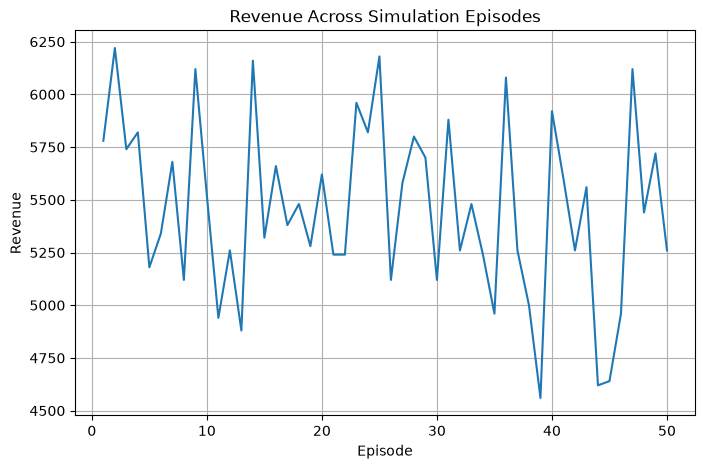

In [5]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Episode"],results_df["Revenue"])

plt.title("Revenue Across Simulation Episodes")

plt.xlabel("Episode")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

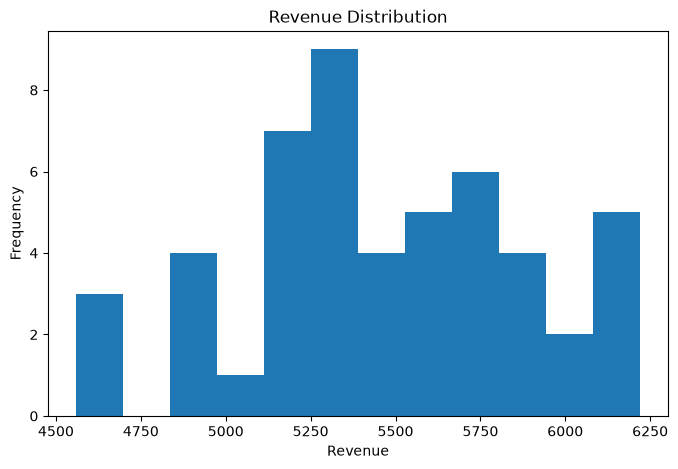

In [6]:
plt.figure(figsize=(8,5))

plt.hist(results_df["Revenue"],bins=12)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()